In [1]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [42]:
# =============================================================================
# IMPORTS, PATHS, CONSTANTS
# =============================================================================

from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Any

import json
import random
import time
import warnings
import pickle

import gymnasium as gym
from gymnasium import spaces

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from tqdm import tqdm, trange

from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# =============================================================================
# EXPERIMENT SETTINGS
# =============================================================================

MASTER_SEED = 42

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)

NUM_RUNS = 10

EPISODE_BUDGET = 1500

BASE_SEED_START = 5000

EPSILON = 0.05

MAX_STEPS = 20

# =============================================================================
# FOURROOMS CONSTANTS
# =============================================================================

FR_ROWS = 11
FR_COLS = 11

FR_N_STATES = 121
FR_N_ACTIONS = 4

FR_GOAL = (0, 10)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path(
    "/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study"
)

AGENT_PATH = (
    ROOT
    / "agents"
    / "dynaq"
    / "fourrooms"
)

RESULTS_DIR = (
    ROOT
    / "results"
    / "fourrooms"
)

RAW_DIR = RESULTS_DIR / "raw"
TABLES_DIR = RESULTS_DIR / "tables"
FIGS_DIR = RESULTS_DIR / "figs"

for p in [
    RESULTS_DIR,
    RAW_DIR,
    TABLES_DIR,
    FIGS_DIR,
]:
    p.mkdir(
        parents=True,
        exist_ok=True,
    )

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

print("Agent:", AGENT_PATH)
print("Results:", RESULTS_DIR)

Agent: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/dynaq/fourrooms
Results: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/fourrooms


In [43]:
# =============================================================================
# FOURROOMS ENVIRONMENT
# =============================================================================

class FourRoomsEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(self):

        super().__init__()

        self.rows = FR_ROWS
        self.cols = FR_COLS

        self.action_space = spaces.Discrete(
            FR_N_ACTIONS
        )

        self.observation_space = spaces.Discrete(
            FR_N_STATES
        )

        self.walls = set()

        for r in range(self.rows):
            self.walls.add((r, 5))

        for c in range(self.cols):
            self.walls.add((5, c))

        for d in [
            (5, 1),
            (5, 9),
            (1, 5),
            (9, 5),
        ]:
            self.walls.discard(d)

        self.goal = FR_GOAL

        self.state = None

    @property
    def valid_states(self):

        return [
            r * self.cols + c
            for r in range(self.rows)
            for c in range(self.cols)
            if (
                (r, c) not in self.walls
                and
                (r, c) != self.goal
            )
        ]

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        rng = np.random.default_rng(seed)

        valid = self.valid_states

        idx = int(
            rng.integers(
                0,
                len(valid),
            )
        )

        pos = self._from_state(valid[idx])

        self.state = pos

        return self._to_state(pos), {}

    def step(self, action):

        r, c = self.state

        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        r = int(np.clip(r, 0, self.rows - 1))
        c = int(np.clip(c, 0, self.cols - 1))

        if (r, c) in self.walls:
            r, c = self.state

        self.state = (r, c)

        if self.state == self.goal:

            return (
                self._to_state(self.state),
                1.0,
                True,
                False,
                {},
            )

        return (
            self._to_state(self.state),
            -0.01,
            False,
            False,
            {},
        )

    def _to_state(self, pos):

        return pos[0] * self.cols + pos[1]

    def _from_state(self, state):

        return (
            state // self.cols,
            state % self.cols,
        )


def make_fourrooms():
    return FourRoomsEnv()


# =============================================================================
# VALID STATES
# =============================================================================

_TMP_ENV = make_fourrooms()

VALID_STATES = _TMP_ENV.valid_states

FR_GOAL_STATE = (
    FR_GOAL[0] * FR_COLS
    + FR_GOAL[1]
)

_TMP_ENV.close()


# =============================================================================
# LOAD AGENT
# =============================================================================

Q = np.load(
    AGENT_PATH
    / "dynaq_Q_fourrooms.npy"
)

assert Q.shape == (
    FR_N_STATES,
    FR_N_ACTIONS,
)
N_STATES = Q.shape[0]
N_ACTIONS = Q.shape[1]
print("Q-table:", Q.shape)

Q-table: (121, 4)


In [44]:
# =============================================================================
# FOURROOMS ENVIRONMENT
# =============================================================================

class FourRoomsEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(self):

        super().__init__()

        self.rows = FR_ROWS
        self.cols = FR_COLS

        self.action_space = spaces.Discrete(
            FR_N_ACTIONS
        )

        self.observation_space = spaces.Discrete(
            FR_N_STATES
        )

        self.walls = set()

        for r in range(self.rows):
            self.walls.add((r, 5))

        for c in range(self.cols):
            self.walls.add((5, c))

        for d in [
            (5, 1),
            (5, 9),
            (1, 5),
            (9, 5),
        ]:
            self.walls.discard(d)

        self.goal = FR_GOAL

        self.state = None

    @property
    def valid_states(self):

        return [
            r * self.cols + c
            for r in range(self.rows)
            for c in range(self.cols)
            if (
                (r, c) not in self.walls
                and
                (r, c) != self.goal
            )
        ]

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        rng = np.random.default_rng(seed)

        valid = self.valid_states

        idx = int(
            rng.integers(
                0,
                len(valid),
            )
        )

        pos = self._from_state(valid[idx])

        self.state = pos

        return self._to_state(pos), {}

    def step(self, action):

        r, c = self.state

        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        r = int(np.clip(r, 0, self.rows - 1))
        c = int(np.clip(c, 0, self.cols - 1))

        if (r, c) in self.walls:
            r, c = self.state

        self.state = (r, c)

        if self.state == self.goal:

            return (
                self._to_state(self.state),
                1.0,
                True,
                False,
                {},
            )

        return (
            self._to_state(self.state),
            -0.01,
            False,
            False,
            {},
        )

    def _to_state(self, pos):

        return pos[0] * self.cols + pos[1]

    def _from_state(self, state):

        return (
            state // self.cols,
            state % self.cols,
        )


def make_fourrooms():
    return FourRoomsEnv()


# =============================================================================
# VALID STATES
# =============================================================================

_TMP_ENV = make_fourrooms()

VALID_STATES = _TMP_ENV.valid_states

FR_GOAL_STATE = (
    FR_GOAL[0] * FR_COLS
    + FR_GOAL[1]
)

_TMP_ENV.close()


# =============================================================================
# LOAD AGENT
# =============================================================================

Q = np.load(
    AGENT_PATH
    / "dynaq_Q_fourrooms.npy"
)

assert Q.shape == (
    FR_N_STATES,
    FR_N_ACTIONS,
)

print("Q-table:", Q.shape)

Q-table: (121, 4)


In [45]:
# =============================================================================
# FOURROOMS ENVIRONMENT
# =============================================================================

class FourRoomsEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(self):

        super().__init__()

        self.rows = FR_ROWS
        self.cols = FR_COLS

        self.action_space = spaces.Discrete(
            FR_N_ACTIONS
        )

        self.observation_space = spaces.Discrete(
            FR_N_STATES
        )

        self.walls = set()

        for r in range(self.rows):
            self.walls.add((r, 5))

        for c in range(self.cols):
            self.walls.add((5, c))

        for d in [
            (5, 1),
            (5, 9),
            (1, 5),
            (9, 5),
        ]:
            self.walls.discard(d)

        self.goal = FR_GOAL

        self.state = None

    @property
    def valid_states(self):

        return [
            r * self.cols + c
            for r in range(self.rows)
            for c in range(self.cols)
            if (
                (r, c) not in self.walls
                and
                (r, c) != self.goal
            )
        ]

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        rng = np.random.default_rng(seed)

        valid = self.valid_states

        idx = int(
            rng.integers(
                0,
                len(valid),
            )
        )

        pos = self._from_state(valid[idx])

        self.state = pos

        return self._to_state(pos), {}

    def step(self, action):

        r, c = self.state

        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        r = int(np.clip(r, 0, self.rows - 1))
        c = int(np.clip(c, 0, self.cols - 1))

        if (r, c) in self.walls:
            r, c = self.state

        self.state = (r, c)

        if self.state == self.goal:

            return (
                self._to_state(self.state),
                1.0,
                True,
                False,
                {},
            )

        return (
            self._to_state(self.state),
            -0.01,
            False,
            False,
            {},
        )

    def _to_state(self, pos):

        return pos[0] * self.cols + pos[1]

    def _from_state(self, state):

        return (
            state // self.cols,
            state % self.cols,
        )


def make_fourrooms():
    return FourRoomsEnv()


# =============================================================================
# VALID STATES
# =============================================================================

_TMP_ENV = make_fourrooms()

VALID_STATES = _TMP_ENV.valid_states

FR_GOAL_STATE = (
    FR_GOAL[0] * FR_COLS
    + FR_GOAL[1]
)

_TMP_ENV.close()


# =============================================================================
# LOAD AGENT
# =============================================================================

Q = np.load(
    AGENT_PATH
    / "dynaq_Q_fourrooms.npy"
)

assert Q.shape == (
    FR_N_STATES,
    FR_N_ACTIONS,
)

print("Q-table:", Q.shape)

Q-table: (121, 4)


In [46]:
# =============================================================================
# PHASE 1 — TCP ONLY
# =============================================================================

def generate_random_pool(
    base_seed,
    budget=EPISODE_BUDGET,
):

    pool = []

    for episode_id in range(budget):

        seed = int(base_seed + episode_id)

        rng = np.random.default_rng(seed)

        state = fr_random_valid_state(rng)

        pool.append({
            "episode_id": episode_id,
            "seed": seed,
            "initial_state": int(state),
        })

    return pool
# ==============================================================================
# TCP METHODS
# ==============================================================================

def tcp_fifo(pool, **_):

    return sorted(pool, key=lambda x: x["episode_id"])

def tcp_random(pool, seed=MASTER_SEED, **_):

    rng = np.random.default_rng(seed)

    shuffled = pool.copy()

    rng.shuffle(shuffled)

    return shuffled

def tcp_entropy(pool, Q, tau=1.0, **_):

    scored = []

    for t in pool:

        probs = _softmax(Q[int(t["initial_state"])], tau)

        ent = float(
            -np.sum(probs * np.log(probs + 1e-12))
        )

        scored.append({**t, "score": ent})

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True
    )

def tcp_margin(pool, Q, **_):

    scored = []

    for t in pool:

        q_sorted = np.sort(
            Q[int(t["initial_state"])]
        )[::-1]

        margin = float(q_sorted[0] - q_sorted[1])

        scored.append({**t, "score": margin})

    return sorted(
        scored,
        key=lambda x: x["score"]
    )

def tcp_confidence(pool, Q, tau=1.0, **_):

    scored = []

    for t in pool:

        probs = _softmax(Q[int(t["initial_state"])], tau)

        conf = float(np.max(probs))

        scored.append({**t, "score": conf})

    return sorted(
        scored,
        key=lambda x: x["score"]
    )

def annotate_pool_returns(pool):

    annotated = []

    for t in pool:

        res = run_episode(
            initial_state=int(
                t["initial_state"]
            ),
            seed=int(
                t["seed"]
            ),
            epsilon=0.0,
        )

        annotated.append({
            **t,
            "return": float(
                res["return"]
            )
        })

    return annotated
def tcp_value_return_gap(pool, Q, **_):

    pool = annotate_pool_returns(pool)

    scored = []

    for t in pool:

        s = int(t["initial_state"])

        pred = float(np.max(Q[s]))

        obs = float(t["return"])

        gap = abs(pred - obs)

        scored.append({**t, "score": gap})

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True
    )

def tcp_q_variance(pool, Q, **_):

    scored = []

    for t in pool:

        var = float(
            np.var(Q[int(t["initial_state"])])
        )

        scored.append({**t, "score": var})

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True
    )

def tcp_state_novelty(pool, **_):

    counts = Counter(
        int(t["initial_state"])
        for t in pool
    )

    scored = []

    for t in pool:

        novelty = 1.0 / counts[int(t["initial_state"])]

        scored.append({
            **t,
            "score": novelty
        })

    return sorted(
        scored,
        key=lambda x: x["score"],
        reverse=True
    )

TCP_REGISTRY = {

    "FIFO": tcp_fifo,

    "Random": tcp_random,

    "Entropy": tcp_entropy,

    "Margin": tcp_margin,

    "Confidence": tcp_confidence,

    "ValueReturnGap": tcp_value_return_gap,

    "QVariance": tcp_q_variance,

    "StateNovelty": tcp_state_novelty,
}

# ==============================================================================
# TCP APPLICATION
# ==============================================================================
def apply_tcp(
    pool,
    tcp_name,
    run_seed,
):

    func = TCP_REGISTRY[tcp_name]

    start = time.perf_counter()

    if tcp_name == "FIFO":

        ordered_pool = func(pool)

    elif tcp_name == "Random":

        ordered_pool = func(
            pool,
            seed=run_seed,
        )

    else:

        ordered_pool = func(
            pool,
            Q=Q,
        )

    tcp_time = time.perf_counter() - start

    return ordered_pool, tcp_time


def evaluate_phase1_pool(
    ordered_pool,
    tcp_time,
):

    rows = []

    for test in ordered_pool:

        result = run_episode(
            initial_state=int(
                test["initial_state"]
            ),
            seed=int(
                test["seed"]
            ),
            epsilon=EPSILON,
        )

        rows.append(result)

    df = pd.DataFrame(rows)

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return metrics


def run_phase1_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 1 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    pool = generate_random_pool(
        base_seed=base_seed,
        budget=EPISODE_BUDGET,
    )

    rows = []

    for tcp_name in TCP_REGISTRY:

        ordered_pool, tcp_time = apply_tcp(
            pool,
            tcp_name,
            base_seed,
        )

        metrics = evaluate_phase1_pool(
            ordered_pool,
            tcp_time,
        )

        row = {
            "run_id": run_id,
            "TCP": tcp_name,
        }

        row.update(metrics)

        rows.append(row)

        print(
            f"{tcp_name:<18}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase1_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase1_results.csv",
        index=False,
    )

    return results


def summarize_phase1(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby("TCP")[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(col)
        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase1_aggregate.csv",
        index=False,
    )

    return agg

In [47]:
def fr_decode(s: int) -> Tuple[int, int]:
    return (int(s) // FR_COLS, int(s) % FR_COLS)

def fr_encode(row: int, col: int) -> int:
    return int(row) * FR_COLS + int(col)

def fr_manhattan(s_a: int, s_b: int) -> int:
    r_a, c_a = fr_decode(s_a)
    r_b, c_b = fr_decode(s_b)
    return abs(r_a - r_b) + abs(c_a - c_b)

def fr_random_valid_state(rng: np.random.Generator) -> int:
    idx = int(rng.integers(0, len(VALID_STATES)))
    return VALID_STATES[idx]

def fr_is_valid(s: int) -> bool:
    return s in VALID_STATES

def run_episode(initial_state,seed,epsilon=EPSILON,):
    env = make_fourrooms()
    env.reset(seed=int(seed))
    env.state = fr_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    steps = 0
    total_reward = 0.0

    t0 = time.perf_counter()

    while not done and steps < MAX_STEPS:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated
        total_reward += float(reward)
        state = int(next_state)
        steps += 1

    env.close()

    success = bool(state == FR_GOAL_STATE)
    failure = int(not success)

    return {
        "return": float(total_reward),
        "success": int(success),
        "failure": int(failure),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }
def _softmax(q_values: np.ndarray, tau: float = 1.0) -> np.ndarray:
    q = q_values / tau
    q = q - np.max(q)
    e = np.exp(q)
    return e / np.sum(e)
def compute_metrics(df, tcp_time=0.0):

    failures = df["failure"].values.astype(int)

    times = df["time"].values.astype(float)

    n = len(failures)

    total_failures = int(np.sum(failures))

    FR = total_failures / n

    if total_failures > 0:

        first_idx = int(
            np.where(failures == 1)[0][0]
        )

        TTF_tests = first_idx + 1

        TTF_time = np.sum(times[:first_idx+1])

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = np.where(failures == 1)[0] + 1

        APFD = (
            1
            - np.sum(positions)/(n * total_failures)
            + 1/(2*n)
        )

    else:

        APFD = np.nan

    if total_failures > 0:

        cum_time = np.cumsum(times)

        fail_times = cum_time[np.where(failures == 1)[0]]

        total_time = cum_time[-1]

        APFD_time = (
            1
            - np.sum(fail_times)/(total_time * total_failures)
            + 1/(2 * total_time)
        )

    else:

        APFD_time = np.nan

    return {

        "FR": float(FR),

        "TTF_tests": float(TTF_tests),

        "TTF_time": float(TTF_time),

        "APFD": float(APFD),

        "APFD_time": float(APFD_time),

        "TCP_time": float(tcp_time),

        "Per_test_overhead": float(tcp_time / n),
    }

def evaluate_ordered_pool(
    ordered_pool,
    tcp_time,
):

    rows = []

    for t in ordered_pool:

        res = run_episode(
            int(t["initial_state"]),
            int(t["seed"]),
            epsilon=EPSILON,
        )

        rows.append(res)

    df = pd.DataFrame(rows)

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time
    )

    return df, metrics
# ==============================================================================
# FRAMEWORK: INDAGO
# ==============================================================================
#
# Literature (Perez et al.):
#   Large candidate pool → label subset by execution → train RandomForest →
#   score all candidates by predicted failure probability → keep top-K.
#
# FourRooms adaptation:
#   Features: row, col, dist_to_goal, q_max, q_var, q_gap, entropy.
#   All candidate states restricted to VALID_STATES.
def _fr_indago_features(state: int) -> List[float]:
    row, col = fr_decode(state)
    dist_goal = fr_manhattan(state, FR_GOAL_STATE)

    q_row = Q[state]
    q_max = float(np.max(q_row))
    q_var = float(np.var(q_row))

    q_sorted = np.sort(q_row)[::-1]
    q_gap = float(q_sorted[0] - q_sorted[1]) if N_ACTIONS >= 2 else 0.0

    probs = _softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    room_id = (0 if row < 5 else 1) * 2 + (0 if col < 5 else 1)

    doorway_dist = min(
        abs(row - 5) + abs(col - 1),
        abs(row - 5) + abs(col - 9),
        abs(row - 1) + abs(col - 5),
        abs(row - 9) + abs(col - 5),
    )

    return [
        float(row),
        float(col),
        float(room_id),
        float(dist_goal),
        float(doorway_dist),
        q_max,
        q_var,
        q_gap,
        entropy,
    ]


def generate_tests_indago(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    pool_size: int = 3000,
    train_size: int = 600,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)

    pool = []
    for i in range(pool_size):
        seed = int(base_seed + i)
        s = fr_random_valid_state(np.random.default_rng(seed))
        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(s),
        })

    train_size = min(train_size, pool_size)
    label_idx = rng.choice(pool_size, size=train_size, replace=False)

    X_train = []
    y_train = []
    label_info = {}

    for idx in label_idx:
        idx = int(idx)
        t = pool[idx]
        s = int(t["initial_state"])
        res = run_episode(
            initial_state=s,
            seed=int(t["seed"]),
            epsilon=0.0,
        )

        X_train.append(_fr_indago_features(s))
        y_train.append(int(res["failure"]))

        label_info[idx] = {
            "return": float(res["return"]),
            "success": int(res["success"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
        }

    y_train = np.array(y_train)

    if len(np.unique(y_train)) < 2:
        scores = []
        for t in pool:
            s = int(t["initial_state"])
            feats = _fr_indago_features(s)
            heuristic = feats[-1] + feats[6] + feats[3]
            scores.append(float(heuristic))
    else:
        clf = RandomForestClassifier(
            n_estimators=200,
            random_state=base_seed,
            class_weight="balanced",
            n_jobs=-1,
        )

        clf.fit(np.array(X_train), y_train)

        X_all = np.array([
            _fr_indago_features(int(t["initial_state"]))
            for t in pool
        ])

        scores = clf.predict_proba(X_all)[:, 1]

    sel_idx = np.argsort(-np.array(scores))[:budget]

    test_pool = []
    for rank, idx in enumerate(sel_idx):
        idx = int(idx)
        t = pool[idx].copy()
        t["episode_id"] = rank
        t["indago_score"] = float(scores[idx])

        if idx in label_info:
            t.update(label_info[idx])

        test_pool.append(t)

    return test_pool

# ==============================================================================
# FRAMEWORK: STARLA
# ==============================================================================
#
# Literature (Acharya et al.):
#   Genetic-algorithm search guided by risk proxy (Q-gap + dist-to-goal).
#   Fitness = 10 × failure + risk_proxy(state) − 0.1 × return.
#
# FourRooms adaptation:
#   State mutation: perturb (row, col) by ±1, clamp to grid, reject walls.

def _fr_risk_proxy(state: int) -> float:
    row, col = fr_decode(state)

    q_row = Q[int(state)]
    q_sorted = np.sort(q_row)[::-1]
    q_gap = float(q_sorted[0] - q_sorted[1]) if N_ACTIONS >= 2 else 0.0

    probs = _softmax(q_row)
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)))

    dist_goal = fr_manhattan(state, FR_GOAL_STATE)

    doorway_dist = min(
        abs(row - 5) + abs(col - 1),
        abs(row - 5) + abs(col - 9),
        abs(row - 1) + abs(col - 5),
        abs(row - 9) + abs(col - 5),
    )

    return float(
        entropy
        + 1.0 / (q_gap + 1e-6)
        + 0.25 * dist_goal
        + 0.25 * doorway_dist
    )


def _fr_mutate_state(state: int, rng: np.random.Generator) -> int:
    row, col = fr_decode(state)

    for _ in range(20):
        dr = int(rng.choice([-1, 0, 1]))
        dc = int(rng.choice([-1, 0, 1]))

        new_row = int(np.clip(row + dr, 0, FR_ROWS - 1))
        new_col = int(np.clip(col + dc, 0, FR_COLS - 1))
        new_s = fr_encode(new_row, new_col)

        if fr_is_valid(new_s):
            return int(new_s)

    return fr_random_valid_state(rng)


def _fr_eval_state_fast(state: int, seed: int) -> Tuple[float, int, int]:
    res = run_episode(
        initial_state=state,
        seed=seed,
        epsilon=0.0,
    )
    return float(res["return"]), int(res["steps"]), int(res["failure"])


def generate_tests_starla(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    pop_size: int = 100,
    elite_frac: float = 0.5,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)
    gens = int(np.ceil(budget / pop_size))

    pop = [fr_random_valid_state(rng) for _ in range(pop_size)]
    pool = []

    for _gen in trange(gens, desc="STARLA: evolving", leave=False):
        scored = []

        for state in pop:
            if len(pool) >= budget:
                break

            seed_ep = int(base_seed + len(pool))
            ret, steps, fail = _fr_eval_state_fast(state, seed_ep)

            fitness = (
                100.0 * fail
                + 1.0 * steps
                + abs(ret)
                + _fr_risk_proxy(state)
            )

            pool.append({
                "episode_id": len(pool),
                "seed": seed_ep,
                "initial_state": int(state),
                "return": float(ret),
                "failure": int(fail),
                "steps": int(steps),
                "starla_fitness": float(fitness),
            })

            scored.append((fitness, int(state)))

        if len(pool) >= budget:
            break

        scored.sort(key=lambda x: x[0], reverse=True)

        n_elite = max(1, int(pop_size * elite_frac))
        parents = [s for _, s in scored[:n_elite]]

        offspring = []
        while len(offspring) < pop_size - n_elite:
            parent = int(rng.choice(parents))
            offspring.append(_fr_mutate_state(parent, rng))

        pop = parents + offspring

    return pool[:budget]
# ==============================================================================
# FRAMEWORK: QD-TESTING
# ==============================================================================
#
# Literature (Castellano et al.):
#   Quality-Diversity archive: cell = BD(state).
#   BD for FourRooms: (room_id, dist_to_goal) — room identified by
#   which quadrant of the 11×11 grid the state falls in.
#   Fitness: lexicographic (failure_flag, −steps).
def _fr_bd(state: int) -> Tuple[int, int, int]:
    row, col = fr_decode(state)

    room_id = (0 if row < 5 else 1) * 2 + (0 if col < 5 else 1)
    dist_bin = min(5, fr_manhattan(state, FR_GOAL_STATE) // 3)

    doorway_dist = min(
        abs(row - 5) + abs(col - 1),
        abs(row - 5) + abs(col - 9),
        abs(row - 1) + abs(col - 5),
        abs(row - 9) + abs(col - 5),
    )
    doorway_bin = min(4, doorway_dist // 2)

    return (int(room_id), int(dist_bin), int(doorway_bin))


def _fr_bd_cell(bd: Tuple[int, int, int]) -> Tuple[int, int, int]:
    return bd


def generate_tests_qd(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    init_seeds: int = 200,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)
    archive = {}
    pool = []

    def _qd_quality(fail: int, steps: int, ret: float) -> Tuple[int, int, float]:
        return (int(fail), int(steps), float(-ret))

    def _try_add(state: int, seed: int):
        ret, steps, fail = _fr_eval_state_fast(state, seed)
        cell = _fr_bd_cell(_fr_bd(state))
        quality = _qd_quality(fail, steps, ret)

        if cell not in archive or quality > archive[cell]["quality"]:
            archive[cell] = {
                "state": int(state),
                "seed": int(seed),
                "quality": quality,
            }

        pool.append({
            "episode_id": len(pool),
            "seed": int(seed),
            "initial_state": int(state),
            "return": float(ret),
            "failure": int(fail),
            "steps": int(steps),
            "qd_cell": str(cell),
            "qd_quality": str(quality),
        })

    for i in trange(init_seeds, desc="QD-Testing: init", leave=False):
        if len(pool) >= budget:
            break
        state = fr_random_valid_state(rng)
        _try_add(state, int(base_seed + i))

    while len(pool) < budget:
        if archive:
            elite = rng.choice(list(archive.values()))
            state = _fr_mutate_state(int(elite["state"]), rng)
        else:
            state = fr_random_valid_state(rng)

        seed_ep = int(base_seed + len(pool))
        _try_add(state, seed_ep)

    return pool[:budget]
# ==============================================================================
# FRAMEWORK: RLMUTATION
# ==============================================================================
#
# Literature (Tappler et al.):
#   Four environment mutants × (budget // 4) episodes each.
#   Mutants wrap FourRoomsEnv; oracle re-runs on clean env via
#   evaluate_ordered_pool.
#
# FourRooms adaptation:
#   RN  — reward noise on goal reward
#   M   — mangled observations (past-step replay)
#   R   — repeated observation (repeat previous step)
#   RA  — random action injection (p=0.15, mild perturbation)
#          WA/worst-action replaced with RA for FourRooms because
#          the env has only 4 actions and worst-action collapses results.
class SlipActionMutant(gym.Wrapper):
    def __init__(self, env, p=0.20):
        super().__init__(env)
        self.p = p

    def step(self, action):
        if np.random.rand() < self.p:
            action = int(np.random.choice([0, 1, 2, 3]))
        return self.env.step(action)


class DoorBlockMutant(gym.Wrapper):

    def __init__(self, env, blocked_door=(1, 5)):
        super().__init__(env)
        self.blocked_door = blocked_door
        self.env.unwrapped.walls.add(blocked_door)

    @property
    def valid_states(self):
        return [
            s for s in self.env.unwrapped.valid_states
            if fr_decode(s) != self.blocked_door
        ]


class StepPenaltyMutant(gym.Wrapper):
    def step(self, action):
        ns, r, term, trunc, info = self.env.step(action)
        if not term:
            r = -0.05
        return ns, r, term, trunc, info


class GoalRewardNoiseMutant(gym.Wrapper):
    def __init__(self, env, sigma=0.15):
        super().__init__(env)
        self.sigma = sigma

    def step(self, action):
        ns, r, term, trunc, info = self.env.step(action)
        if term and r > 0:
            r = float(r + np.random.normal(0.0, self.sigma))
        return ns, r, term, trunc, info


def _make_rlmutation_env(tag: str):
    base = make_fourrooms()

    if tag == "SlipAction":
        return SlipActionMutant(base, p=0.20)

    if tag == "DoorBlock":
        return DoorBlockMutant(base, blocked_door=(1, 5))

    if tag == "StepPenalty":
        return StepPenaltyMutant(base)

    if tag == "GoalRewardNoise":
        return GoalRewardNoiseMutant(base, sigma=0.15)

    return base


def _run_episode_mutant_fr(env, Q, initial_state, seed, epsilon=0.0):
    env.reset(seed=int(seed))
    env.unwrapped.state = fr_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    steps = 0
    total_reward = 0.0

    t0 = time.perf_counter()

    while not done and steps < MAX_STEPS:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        ns, reward, term, trunc, _ = env.step(action)

        done = term or trunc
        total_reward += float(reward)
        state = int(ns)
        steps += 1

    success = bool(state == FR_GOAL_STATE)

    return {
        "return": float(total_reward),
        "success": int(success),
        "failure": int(not success),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }


def generate_tests_rlmutation(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
) -> List[Dict]:

    mutant_tags = ["SlipAction", "DoorBlock", "StepPenalty", "GoalRewardNoise"]
    share = int(np.ceil(budget / len(mutant_tags)))

    pool = []

    for k, tag in enumerate(mutant_tags):
        for i in tqdm(range(share), desc=f"RLMutation [{tag}]", leave=False):
            if len(pool) >= budget:
                break

            seed_ep = int(base_seed + k * share + i)
            state = fr_random_valid_state(np.random.default_rng(seed_ep))

            if tag == "DoorBlock" and fr_decode(state) == (1, 5):
                state = fr_random_valid_state(np.random.default_rng(seed_ep + 999))

            env_m = _make_rlmutation_env(tag)
            res = _run_episode_mutant_fr(env_m, Q, state, seed_ep, epsilon=0.0)
            env_m.close()

            pool.append({
                "episode_id": len(pool),
                "seed": seed_ep,
                "initial_state": int(state),
                "mutant": tag,
                "return": float(res["return"]),
                "success": int(res["success"]),
                "failure": int(res["failure"]),
                "steps": int(res["steps"]),
                "mutant_failure": int(res["failure"]),
            })
    rng = np.random.default_rng(base_seed + 12345)
    rng.shuffle(pool)

    for i, t in enumerate(pool):
        t["episode_id"] = i
    return pool[:budget]


def evaluate_ordered_pool_rlmutation(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        state = int(test["initial_state"])
        seed = int(test["seed"])
        tag = test.get("mutant", "NONE")

        env_m = _make_rlmutation_env(tag)
        result = _run_episode_mutant_fr(env_m, Q, state, seed, epsilon=0.0)
        env_m.close()

        rows.append({
            "initial_state": state,
            "mutant": tag,
            "return": float(result["return"]),
            "success": int(result["success"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics
# ==============================================================================
# FRAMEWORK: MDPFUZZ
# ==============================================================================
#
# Literature (Qi et al.):
#   Coverage-guided fuzzing. Corpus = failure-eliciting or coverage-novel states.
#   Coverage = unique BD cells. Mutation = grid perturbation of (row, col).
def _run_episode_trace_fr(Q, initial_state, seed, epsilon=0.0, max_steps=MAX_STEPS):
    env = make_fourrooms()
    env.reset(seed=int(seed))
    env.state = fr_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    total_reward = 0.0
    steps = 0
    visited = [state]

    t0 = time.perf_counter()

    while not done and steps < max_steps:
        if rng.random() < epsilon:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        ns, reward, term, trunc, _ = env.step(action)

        done = term or trunc
        total_reward += float(reward)
        state = int(ns)
        visited.append(state)
        steps += 1

    env.close()

    success = bool(state == FR_GOAL_STATE)

    return {
        "return": float(total_reward),
        "success": int(success),
        "failure": int(not success),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
        "visited": visited,
    }


def _mdpfuzz_coverage_cells_fr(visited_states):
    cells = set()

    for s in visited_states:
        row, col = fr_decode(int(s))

        room_id = (0 if row < 5 else 1) * 2 + (0 if col < 5 else 1)
        local_row = row // 2
        local_col = col // 2

        cells.add((int(room_id), int(local_row), int(local_col)))

    return cells


def generate_tests_mdpfuzz(
    base_seed: int,
    budget: int = EPISODE_BUDGET,
    init_size: int = 300,
) -> List[Dict]:

    rng = np.random.default_rng(base_seed)

    corpus = []
    global_coverage = set()
    pool = []

    for i in trange(init_size, desc="MDPFuzz: init corpus", leave=False):
        if len(pool) >= budget:
            break

        seed_ep = int(base_seed + i)
        state = fr_random_valid_state(rng)

        res = _run_episode_trace_fr(Q, state, seed_ep, epsilon=0.0)
        cells = _mdpfuzz_coverage_cells_fr(res["visited"])
        new_cells = cells - global_coverage

        if res["failure"] or new_cells:
            corpus.append(int(state))
            global_coverage |= cells

        pool.append({
            "episode_id": len(pool),
            "seed": seed_ep,
            "initial_state": int(state),
            "return": float(res["return"]),
            "success": int(res["success"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
            "coverage_gain": int(len(new_cells)),
        })

    if not corpus:
        corpus = [p["initial_state"] for p in pool[:min(50, len(pool))]]

    while len(pool) < budget:
        parent = int(rng.choice(corpus))
        state = _fr_mutate_state(parent, rng)
        seed_ep = int(base_seed + len(pool))

        res = _run_episode_trace_fr(Q, state, seed_ep, epsilon=0.0)
        cells = _mdpfuzz_coverage_cells_fr(res["visited"])
        new_cells = cells - global_coverage

        if res["failure"] or new_cells:
            corpus.append(int(state))
            global_coverage |= cells

        pool.append({
            "episode_id": len(pool),
            "seed": seed_ep,
            "initial_state": int(state),
            "return": float(res["return"]),
            "success": int(res["success"]),
            "failure": int(res["failure"]),
            "steps": int(res["steps"]),
            "coverage_gain": int(len(new_cells)),
        })

    return pool[:budget]
# ==============================================================================
# FRAMEWORK: NR-RL
# ==============================================================================
#
# Literature (Nakamura et al.):
#   Natural Robustness testing.
#   TCP ranks by clean Q-table signals on the initial state.
#   Perturbation (p=0.10 random action) applied during execution only.
#   FourRooms has deterministic transitions, so mild random injection is
#   sufficient to expose robustness failures without collapsing results.
NR_RL_P_RAND = 0.10


def generate_tests_nrrl(base_seed: int, budget: int = EPISODE_BUDGET) -> List[Dict]:
    pool = []

    for i in range(budget):
        seed = int(base_seed + i)
        s = fr_random_valid_state(np.random.default_rng(seed))

        pool.append({
            "episode_id": i,
            "seed": seed,
            "initial_state": int(s),
        })

    return pool


def run_episode_nrrl_fr(
    Q: np.ndarray,
    initial_state: int,
    seed: int,
    p_rand: float = NR_RL_P_RAND,
    max_steps: int = MAX_STEPS,
) -> Dict:

    env = make_fourrooms()
    env.reset(seed=int(seed))
    env.state = fr_decode(int(initial_state))

    rng = np.random.default_rng(int(seed))
    state = int(initial_state)
    done = False
    total_reward = 0.0
    steps = 0

    t0 = time.perf_counter()

    while not done and steps < max_steps:
        if rng.random() < p_rand:
            action = int(rng.integers(0, N_ACTIONS))
        else:
            action = int(np.argmax(Q[state]))

        ns, reward, term, trunc, _ = env.step(action)

        done = term or trunc
        total_reward += float(reward)
        state = int(ns)
        steps += 1

    env.close()

    success = bool(state == FR_GOAL_STATE)

    return {
        "return": float(total_reward),
        "success": int(success),
        "failure": int(not success),
        "steps": int(steps),
        "time": float(time.perf_counter() - t0),
    }


def evaluate_ordered_pool_nrrl(
    ordered_pool: List[Dict],
    Q: np.ndarray,
    tcp_time: float,
) -> Tuple[pd.DataFrame, Dict]:

    rows = []

    for test in ordered_pool:
        result = run_episode_nrrl_fr(
            Q,
            initial_state=int(test["initial_state"]),
            seed=int(test["seed"]),
            p_rand=NR_RL_P_RAND,
            max_steps=MAX_STEPS,
        )

        rows.append({
            "initial_state": int(test["initial_state"]),
            "return": float(result["return"]),
            "success": int(result["success"]),
            "failure": int(result["failure"]),
            "steps": int(result["steps"]),
            "time": float(result["time"]),
        })

    df = pd.DataFrame(rows)
    metrics = compute_metrics(df, tcp_time=tcp_time)
    return df, metrics

# ==============================================================================
# FRAMEWORK REGISTRY
# ==============================================================================

FRAMEWORK_REGISTRY: Dict[str, Dict] = {
    "Indago"     : {"gen": generate_tests_indago,      "eval": evaluate_ordered_pool},
    "STARLA"     : {"gen": generate_tests_starla,      "eval": evaluate_ordered_pool},
    "QD-Testing" : {"gen": generate_tests_qd,          "eval": evaluate_ordered_pool},
    "RLMutation" : {"gen": generate_tests_rlmutation,  "eval": evaluate_ordered_pool_rlmutation},
    "MDPFuzz"    : {"gen": generate_tests_mdpfuzz,     "eval": evaluate_ordered_pool},
    "NR-RL"      : {"gen": generate_tests_nrrl,        "eval": evaluate_ordered_pool_nrrl},
}


In [48]:
# =============================================================================
# PHASE 2 — FRAMEWORK-INTEGRATED TCP
# =============================================================================

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id + 1} "
        f"(seed={base_seed})"
    )

    rows = []

    for framework_name, framework in FRAMEWORK_REGISTRY.items():

        print(
            f"\n[{framework_name}] Generating test pool..."
        )

        t0 = time.perf_counter()

        test_pool = framework["gen"](
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
        )

        generation_time = (
            time.perf_counter() - t0
        )

        for i, test in enumerate(test_pool):

            if "episode_id" not in test:
                test["episode_id"] = i

        eval_fn = framework["eval"]

        for tcp_name in TCP_REGISTRY:

            ordered_pool, tcp_time = apply_tcp(
                test_pool,
                tcp_name,
                run_seed=base_seed,
            )

            if eval_fn is evaluate_ordered_pool:

                df, metrics = eval_fn(
                    ordered_pool,
                    tcp_time,
                )

            else:

                df, metrics = eval_fn(
                    ordered_pool,
                    Q,
                    tcp_time,
                )

            row = {
                "run_id": run_id,
                "framework": framework_name,
                "tcp": tcp_name,
                "generation_time": generation_time,
            }

            row.update(metrics)

            rows.append(row)

            print(
                f"{tcp_name:<18}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(num_runs):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(rows)

    results = pd.DataFrame(all_rows)

    results.to_csv(
        TABLES_DIR / "phase2_results.csv",
        index=False,
    )

    return results


def summarize_phase2(results):

    metrics = [
        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (
        results
        .groupby(
            ["framework", "tcp"]
        )[metrics]
        .agg(["mean", "std"])
        .round(6)
    )

    agg.columns = [
        "_".join(c)
        for c in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR / "phase2_aggregate.csv",
        index=False,
    )

    return agg

In [49]:
# =============================================================================
# STATISTICS
# =============================================================================

def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    gt = sum(
        xi > yj
        for xi in x
        for yj in y
    )

    lt = sum(
        xi < yj
        for xi in x
        for yj in y
    )

    return (gt - lt) / (nx * ny)


def phase1_statistics(results):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results["TCP"].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({
            "TCP": tcp,
            "p_value": p,
            "cliffs_delta": cliffs_delta(
                vals,
                fifo,
            ),
        })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase1_statistics.csv",
        index=False,
    )

    return stat_df


def phase2_statistics(results):

    rows = []

    for framework in results["framework"].unique():

        subset = results[
            results["framework"] == framework
        ]

        fifo = subset[
            subset["tcp"] == "FIFO"
        ]["APFD"].values

        for tcp in subset["tcp"].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["tcp"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({
                "framework": framework,
                "tcp": tcp,
                "p_value": p,
                "cliffs_delta": cliffs_delta(
                    vals,
                    fifo,
                ),
            })

    stat_df = pd.DataFrame(rows)

    stat_df.to_csv(
        TABLES_DIR / "phase2_statistics.csv",
        index=False,
    )

    return stat_df

In [50]:
# =============================================================================
# ESSENTIAL PLOTS
# =============================================================================

TCP_COLOR_MAP = {
    "FIFO": "#4D4D4D",
    "Random": "#9E9E9E",
    "Entropy": "#1F77B4",
    "Margin": "#FF7F0E",
    "Confidence": "#2CA02C",
    "ValueReturnGap": "#9467BD",
    "QVariance": "#8C564B",
    "StateNovelty": "#A6CEE3",
}

TCP_ORDER = [
    "FIFO",
    "Random",
    "Entropy",
    "Margin",
    "Confidence",
    "ValueReturnGap",
    "QVariance",
    "StateNovelty",
]


def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(
        ordered.index,
        ordered["APFD_mean"],
        color=[
            TCP_COLOR_MAP[t]
            for t in ordered.index
        ],
        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")
    plt.title("Fourrooms Phase 1")

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot("phase1_apfd")

    plt.show()


def plot_phase2_apfd(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["APFD_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_apfd")

    plt.show()


def plot_phase2_overhead(agg):

    frameworks = agg["framework"].unique()

    fig, axes = plt.subplots(
        1,
        len(frameworks),
        figsize=(4 * len(frameworks), 3),
        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, framework in zip(
        axes,
        frameworks,
    ):

        subset = (
            agg[
                agg["framework"] == framework
            ]
            .set_index("tcp")
            .reindex(TCP_ORDER)
        )

        ax.bar(
            subset.index,
            subset["TCP_time_mean"],
            color=[
                TCP_COLOR_MAP[t]
                for t in subset.index
            ],
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(framework)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot("phase2_overhead")

    plt.show()

FOURROOMS TCP REPLICATION

Running Phase 1...

Phase 1 | Run 1 (seed=5000)
FIFO              APFD=0.4652
Random            APFD=0.4935
Entropy           APFD=0.7911
Margin            APFD=0.6217
Confidence        APFD=0.8125
ValueReturnGap    APFD=0.9288
QVariance         APFD=0.2069
StateNovelty      APFD=0.4990

Phase 1 | Run 2 (seed=15000)
FIFO              APFD=0.5754
Random            APFD=0.4794
Entropy           APFD=0.7466
Margin            APFD=0.6351
Confidence        APFD=0.7476
ValueReturnGap    APFD=0.9322
QVariance         APFD=0.2510
StateNovelty      APFD=0.5757

Phase 1 | Run 3 (seed=25000)
FIFO              APFD=0.5515
Random            APFD=0.5082
Entropy           APFD=0.7860
Margin            APFD=0.6157
Confidence        APFD=0.7531
ValueReturnGap    APFD=0.9270
QVariance         APFD=0.2114
StateNovelty      APFD=0.4844

Phase 1 | Run 4 (seed=35000)
FIFO              APFD=0.5109
Random            APFD=0.4735
Entropy           APFD=0.7912
Margin            APFD=0.

FIFO              APFD=0.3534
Random            APFD=0.4908
Entropy           APFD=0.6543
Margin            APFD=0.4208
Confidence        APFD=0.6603
ValueReturnGap    APFD=0.6805
QVariance         APFD=0.3518
StateNovelty      APFD=0.3248

[QD-Testing] Generating test pool...


FIFO              APFD=0.4569
Random            APFD=0.4840
Entropy           APFD=0.7936
Margin            APFD=0.6399
Confidence        APFD=0.8408
ValueReturnGap    APFD=0.9514
QVariance         APFD=0.2060
StateNovelty      APFD=0.4508

[RLMutation] Generating test pool...


FIFO              APFD=0.5122
Random            APFD=0.4825
Entropy           APFD=0.6245
Margin            APFD=0.5146
Confidence        APFD=0.5662
ValueReturnGap    APFD=0.7304
QVariance         APFD=0.3855
StateNovelty      APFD=0.4920

[MDPFuzz] Generating test pool...


FIFO              APFD=0.4744
Random            APFD=0.4496
Entropy           APFD=0.7592
Margin            APFD=0.6047
Confidence        APFD=0.7626
ValueReturnGap    APFD=0.8987
QVariance         APFD=0.2395
StateNovelty      APFD=0.2823

[NR-RL] Generating test pool...
FIFO              APFD=0.4975
Random            APFD=0.4804
Entropy           APFD=0.7224
Margin            APFD=0.5784
Confidence        APFD=0.7126
ValueReturnGap    APFD=0.9052
QVariance         APFD=0.2729
StateNovelty      APFD=0.4949

Phase 2 | Run 2 (seed=15000)

[Indago] Generating test pool...
FIFO              APFD=0.8391
Random            APFD=0.5455
Entropy           APFD=0.7431
Margin            APFD=0.7857
Confidence        APFD=0.7405
ValueReturnGap    APFD=0.8747
QVariance         APFD=0.2519
StateNovelty      APFD=0.4622

[STARLA] Generating test pool...


...

FIFO              APFD=0.4470
Random            APFD=0.5127
Entropy           APFD=0.7965
Margin            APFD=0.6257
Confidence        APFD=0.8459
ValueReturnGap    APFD=0.9333
QVariance         APFD=0.2058
StateNovelty      APFD=0.3233

[NR-RL] Generating test pool...
FIFO              APFD=0.5290
Random            APFD=0.5036
Entropy           APFD=0.7255
Margin            APFD=0.6249
Confidence        APFD=0.7429
ValueReturnGap    APFD=0.9161
QVariance         APFD=0.2730
StateNovelty      APFD=0.4473

Phase 2 | Run 10 (seed=95000)

[Indago] Generating test pool...
FIFO              APFD=0.7982
Random            APFD=0.5450
Entropy           APFD=0.7301
Margin            APFD=0.7214
Confidence        APFD=0.6905
ValueReturnGap    APFD=0.8644
QVariance         APFD=0.2623
StateNovelty      APFD=0.5787

[STARLA] Generating test pool...


FIFO              APFD=0.3933
Random            APFD=0.5063
Entropy           APFD=0.6142
Margin            APFD=0.4419
Confidence        APFD=0.6183
ValueReturnGap    APFD=0.6446
QVariance         APFD=0.3978
StateNovelty      APFD=0.3699

[QD-Testing] Generating test pool...


FIFO              APFD=0.4593
Random            APFD=0.4422
Entropy           APFD=0.8300
Margin            APFD=0.5839
Confidence        APFD=0.8121
ValueReturnGap    APFD=0.9512
QVariance         APFD=0.1680
StateNovelty      APFD=0.3469

[RLMutation] Generating test pool...


FIFO              APFD=0.4993
Random            APFD=0.5027
Entropy           APFD=0.6114
Margin            APFD=0.5095
Confidence        APFD=0.5794
ValueReturnGap    APFD=0.7118
QVariance         APFD=0.4032
StateNovelty      APFD=0.5313

[MDPFuzz] Generating test pool...


FIFO              APFD=0.4195
Random            APFD=0.5023
Entropy           APFD=0.7767
Margin            APFD=0.5863
Confidence        APFD=0.8093
ValueReturnGap    APFD=0.9129
QVariance         APFD=0.2197
StateNovelty      APFD=0.2476

[NR-RL] Generating test pool...
FIFO              APFD=0.5228
Random            APFD=0.5409
Entropy           APFD=0.7584
Margin            APFD=0.5590
Confidence        APFD=0.6780
ValueReturnGap    APFD=0.9150
QVariance         APFD=0.2367
StateNovelty      APFD=0.6132

Generating plots...


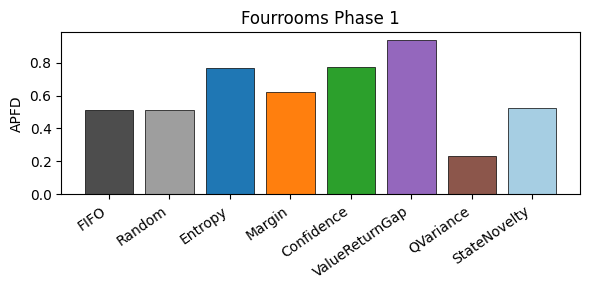

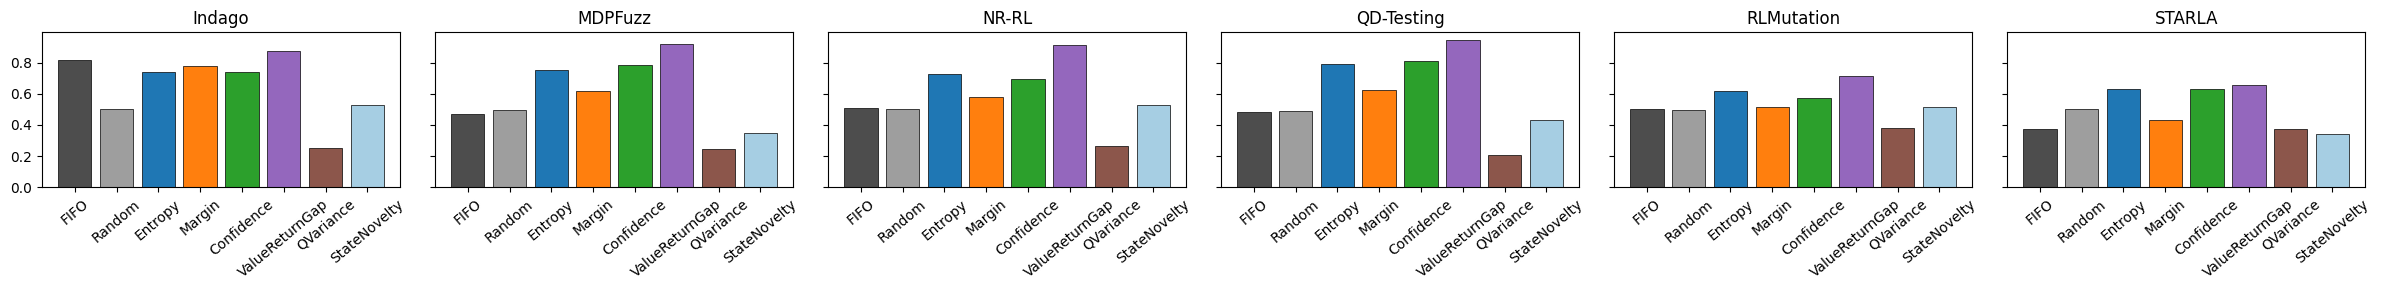

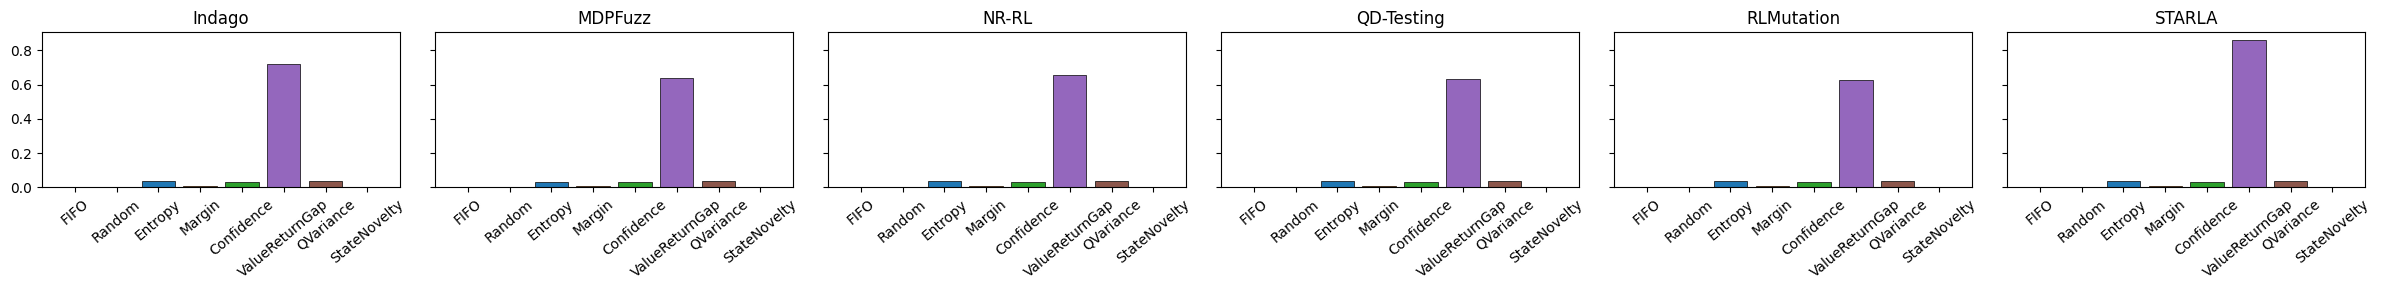


Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/fourrooms/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/fourrooms/figs


In [51]:
# =============================================================================
# MAIN
# =============================================================================

def main():

    print("=" * 70)
    print("FOURROOMS TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")
    phase1_results = run_phase1()

    phase1_agg = summarize_phase1(
        phase1_results
    )

    phase1_stats = phase1_statistics(
        phase1_results
    )

    print("\nRunning Phase 2...")
    phase2_results = run_phase2()

    phase2_agg = summarize_phase2(
        phase2_results
    )

    phase2_stats = phase2_statistics(
        phase2_results
    )

    print("\nGenerating plots...")

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    plot_phase2_overhead(
        phase2_agg
    )

    print(
        f"\nTables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {
        "phase1_results": phase1_results,
        "phase2_results": phase2_results,
    }


if __name__ == "__main__":

    outputs = main()